# Unitary Noise Analysis

This notebook analyzes how noisy the current unitary-compilation models are under quditkit global noise.

It focuses on:
- candidate circuits sampled from existing models
- clean compilation quality against the target unitary
- noisy degradation across a configurable `p` grid
- where the preferred candidate changes as noise increases


In [2]:
from pathlib import Path

from IPython.display import display

from notebooks.shared.bootstrap import setup_notebook_paths

PROJECT_ROOT = setup_notebook_paths()

from notebooks.noise_awareness.unitary_noise_analysis_helper import (
    DEFAULT_P_GRID,
    build_model_specs,
    collect_candidate_tables,
    plot_noise_overview,
    save_analysis_bundle,
    summarize_candidate_tables,
)
from notebooks.noise_awareness.unitary_noise_common import DEFAULT_RESULTS_ROOT, maybe_dataframe


In [7]:
DATASET_PATH = Path("../datasets/curriculum/unitary_stage1_quditkit")
MODEL_DIRS = [
    Path("../models/trained/paper_unitary"),
    Path("../models/remote/qc_unitary_3qubit"),
]
TARGET_LIMIT = 16
SAMPLES_PER_TARGET = 16
P_GRID = list(DEFAULT_P_GRID)
GUIDANCE_SCALE = 4.0
AUTO_BATCH_SIZE = 64
CLEAN_INFidelity_THRESHOLD = 1e-6
NOISE_REALIZATIONS = 8
SEED = 0
DEVICE = "cuda"
OUTPUT_DIR = DEFAULT_RESULTS_ROOT / "unitary_noise_analysis_demo"

print("DATASET_PATH =", DATASET_PATH)
print("MODEL_DIRS =", MODEL_DIRS)
print("P_GRID =", P_GRID)
print("OUTPUT_DIR =", OUTPUT_DIR)


DATASET_PATH = ../datasets/curriculum/unitary_stage1_quditkit
MODEL_DIRS = [PosixPath('../models/trained/paper_unitary'), PosixPath('../models/remote/qc_unitary_3qubit')]
P_GRID = [0.0, 0.01, 0.03, 0.1]
OUTPUT_DIR = /workspace/qcircuit-generation/notebooks/results/noise_aware_unitary/unitary_noise_analysis_demo


In [8]:
model_specs = build_model_specs(MODEL_DIRS)
analysis = collect_candidate_tables(
    DATASET_PATH,
    model_specs=model_specs,
    target_limit=TARGET_LIMIT,
    samples_per_target=SAMPLES_PER_TARGET,
    p_grid=P_GRID,
    guidance_scale=GUIDANCE_SCALE,
    auto_batch_size=AUTO_BATCH_SIZE,
    clean_infidelity_threshold=CLEAN_INFidelity_THRESHOLD,
    noise_realizations=NOISE_REALIZATIONS,
    seed=SEED,
    device=DEVICE,
)
summary = summarize_candidate_tables(analysis["candidate_rows"], analysis["score_rows"])

display(maybe_dataframe(analysis["overview"]))


[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/curriculum/unitary_stage1_quditkit/dataset/ds_x.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/curriculum/unitary_stage1_quditkit/dataset/ds_y.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/curriculum/unitary_stage1_quditkit/dataset/ds_U.safetensors` onto device: cuda.
[INFO]: Loading tensor from `/workspace/qcircuit-generation/datasets/curriculum/unitary_stage1_quditkit/dataset/ds_z.safetensors` onto device: cuda.
[INFO]: Instantiated config_dataset from given config on cuda.
[INFO]: `genQC.models.unet_qc.QC_Compilation_UNet` instantiated from given `config` on cuda.
[INFO]: Loading model from `models/trained/paper_unitary/model.pt` onto device: cuda.
[INFO]: `genQC.models.unet_qc.QC_Compilation_UNet`. Freeze model: True
[INFO]: `my_genQC.models.frozen_open_clip.CachedFrozenOpenCLIPEmbedder` instantiated from g

,dataset_path,dataset_target_count,analyzed_target_count,model_labels,samples_per_target,noise_ps,clean_infidelity_threshold,noise_realizations
0,/workspace/qcircuit-generation/datasets/curric...,768490,16,"[paper_unitary, qc_unitary_3qubit]",16,"[0.0, 0.01, 0.03, 0.1]",0.000001,8


In [9]:
print("Target overview")
display(maybe_dataframe(analysis["target_rows"][:20]))

print("Candidate summary by model")
display(maybe_dataframe(summary["by_model"]))

print("Noise summary by p")
display(maybe_dataframe(summary["by_noise_p"]))

print("Candidate rows")
display(maybe_dataframe(analysis["candidate_rows"][:50]))

print("Noise score rows")
display(maybe_dataframe(analysis["score_rows"][:50]))


Target overview


,target_position,target_index,target_unitary_id,prompt,original_gate_count
0,0,12701,target_012701,"Compile using: ['h', 'z', 'swap']",4
1,1,31487,target_031487,"Compile using: ['z', 'swap']",11
2,2,57820,target_057820,"Compile using: ['h', 'x', 'swap']",4
3,3,134689,target_134689,"Compile using: ['cx', 'x', 'swap']",5
4,4,207325,target_207325,"Compile using: ['z', 'x', 'swap']",6
5,5,236560,target_236560,"Compile using: ['h', 'cx', 'swap']",4
6,6,387030,target_387030,"Compile using: ['h', 'cx', 'z']",7
7,7,392796,target_392796,"Compile using: ['cx', 'z', 'x']",12
8,8,466192,target_466192,"Compile using: ['h', 'cx', 'z', 'x']",11
9,9,489489,target_489489,"Compile using: ['cx', 'x', 'swap']",5


Candidate summary by model


,dataset,paper_unitary,qc_unitary_3qubit
0,"{'valid_candidates': 16, 'mean_clean_infidelit...","{'valid_candidates': 256, 'mean_clean_infideli...","{'valid_candidates': 256, 'mean_clean_infideli..."


Noise summary by p


,0.00,0.01,0.03,0.10
0,"{'rows': 528, 'mean_noisy_score': 0.9342164189...","{'rows': 528, 'mean_noisy_score': 0.9363618465...","{'rows': 528, 'mean_noisy_score': 0.9406674477...","{'rows': 528, 'mean_noisy_score': 0.9461714562..."


Candidate rows


,candidate_id,target_position,target_index,target_unitary_id,source_model,source_rank,is_valid_decode,passes_clean_threshold,prompt,clean_frobenius,clean_infidelity,gate_count,one_qubit_gate_count,two_qubit_gate_count,depth_proxy,gate_name_histogram_json
0,0,0,12701,target_012701,dataset,0,True,False,"Compile using: ['h', 'z', 'swap']",4.563968e-08,0.000214,4,3,1,2,"{""h"": 1, ""swap"": 1, ""z"": 2}"
1,1,0,12701,target_012701,paper_unitary,0,True,False,"Compile using: ['h', 'z', 'swap']",7.999146e+00,1.000000,0,0,0,0,{}
2,2,0,12701,target_012701,paper_unitary,1,True,False,"Compile using: ['h', 'z', 'swap']",7.999146e+00,1.000000,0,0,0,0,{}
3,3,0,12701,target_012701,paper_unitary,2,True,False,"Compile using: ['h', 'z', 'swap']",7.999146e+00,1.000000,0,0,0,0,{}
4,4,0,12701,target_012701,paper_unitary,3,True,False,"Compile using: ['h', 'z', 'swap']",7.999146e+00,1.000000,0,0,0,0,{}
5,5,0,12701,target_012701,paper_unitary,4,True,False,"Compile using: ['h', 'z', 'swap']",7.999146e+00,1.000000,0,0,0,0,{}
6,6,0,12701,target_012701,paper_unitary,5,True,False,"Compile using: ['h', 'z', 'swap']",7.999146e+00,1.000000,0,0,0,0,{}
7,7,0,12701,target_012701,paper_unitary,6,True,False,"Compile using: ['h', 'z', 'swap']",7.999146e+00,1.000000,0,0,0,0,{}
8,8,0,12701,target_012701,paper_unitary,7,True,False,"Compile using: ['h', 'z', 'swap']",7.999146e+00,1.000000,0,0,0,0,{}
9,9,0,12701,target_012701,paper_unitary,8,True,False,"Compile using: ['h', 'z', 'swap']",7.999146e+00,1.000000,0,0,0,0,{}


Noise score rows


,candidate_id,target_position,target_index,target_unitary_id,source_model,noise_p,noise_proxy,noisy_score_mean,noisy_score_std,noisy_score_min,noisy_score_max
0,0,0,12701,target_012701,dataset,0.00,0.00,0.000214,0.000000,0.000214,0.000214
1,0,0,12701,target_012701,dataset,0.01,0.06,0.000214,0.000000,0.000214,0.000214
2,0,0,12701,target_012701,dataset,0.03,0.18,0.250160,0.432920,0.000214,1.000000
3,0,0,12701,target_012701,dataset,0.10,0.60,0.375134,0.484019,0.000214,1.000000
4,1,0,12701,target_012701,paper_unitary,0.00,0.00,1.000000,0.000000,1.000000,1.000000
5,1,0,12701,target_012701,paper_unitary,0.01,0.00,1.000000,0.000000,1.000000,1.000000
6,1,0,12701,target_012701,paper_unitary,0.03,0.00,1.000000,0.000000,1.000000,1.000000
7,1,0,12701,target_012701,paper_unitary,0.10,0.00,1.000000,0.000000,1.000000,1.000000
8,2,0,12701,target_012701,paper_unitary,0.00,0.00,1.000000,0.000000,1.000000,1.000000
9,2,0,12701,target_012701,paper_unitary,0.01,0.00,1.000000,0.000000,1.000000,1.000000


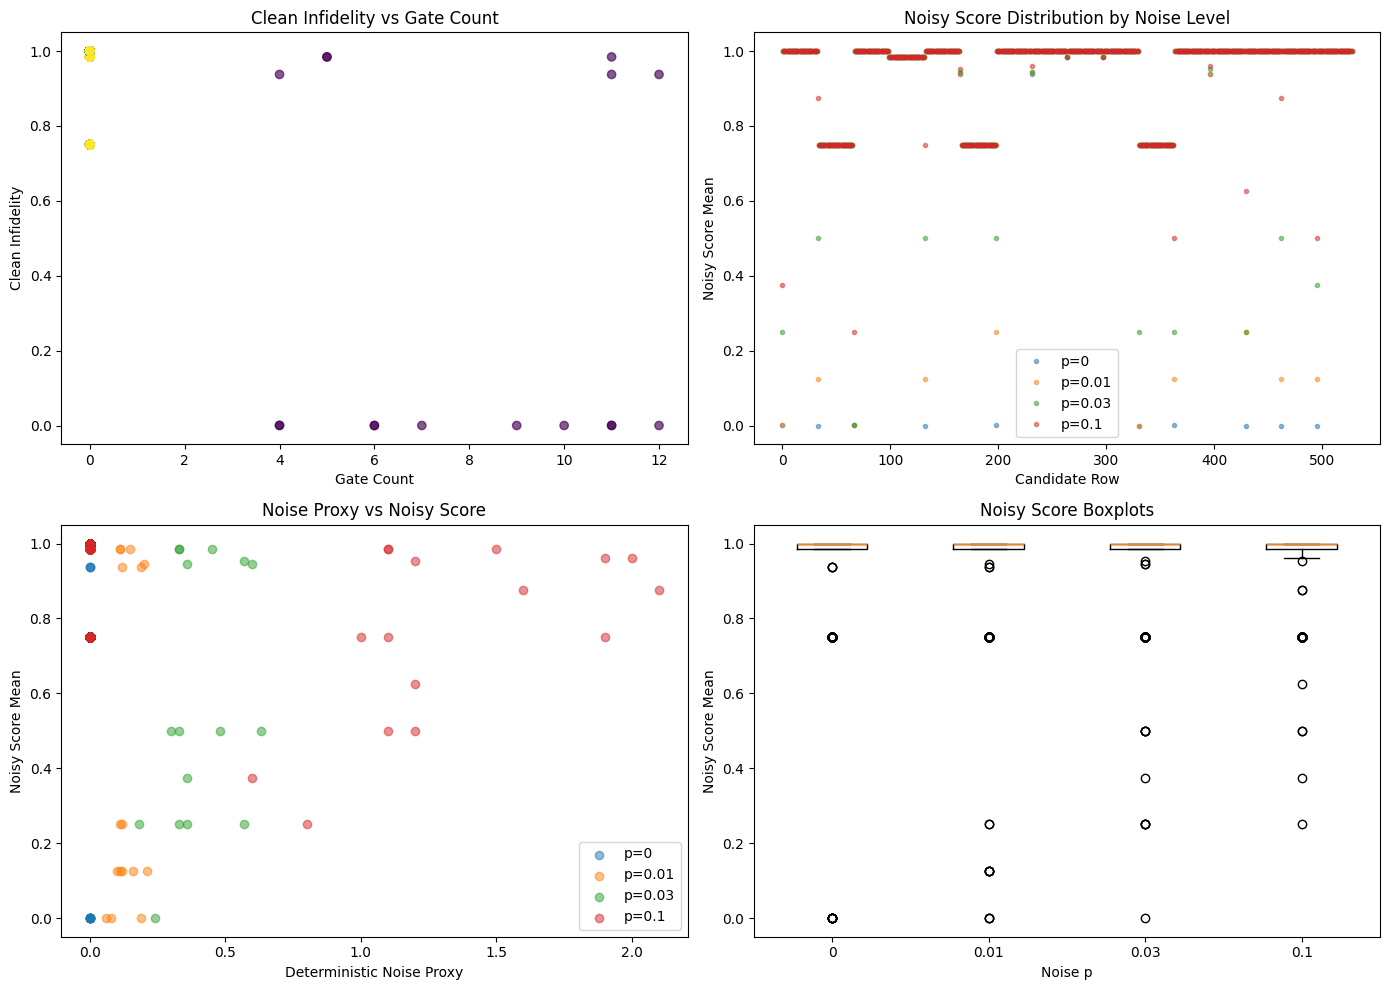

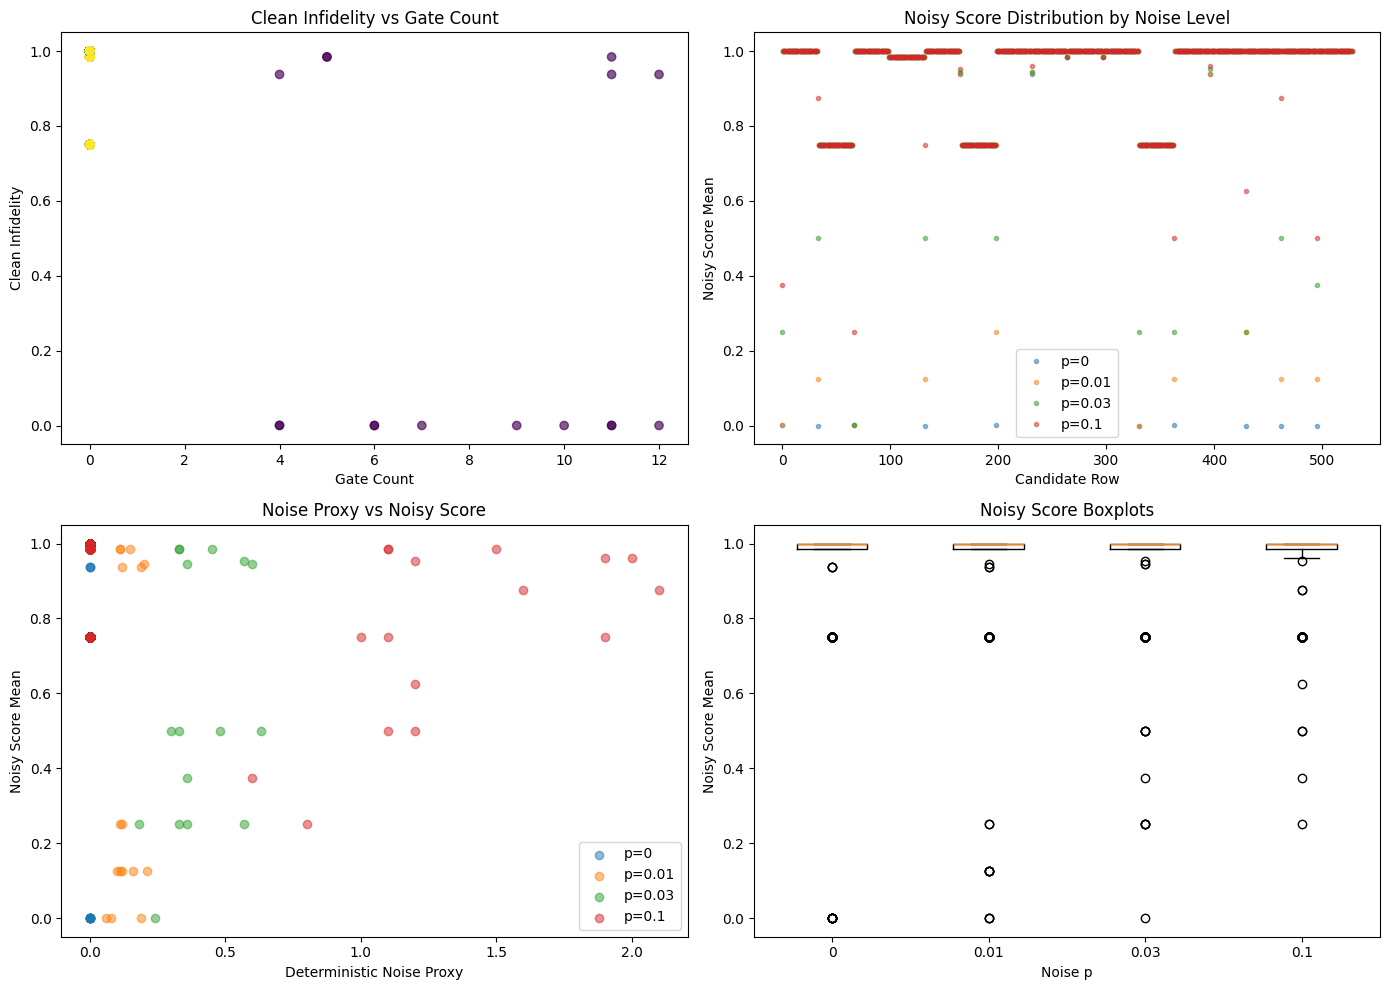

In [10]:
plot_noise_overview(analysis["candidate_rows"], analysis["score_rows"])


In [ ]:
saved_dir = save_analysis_bundle(analysis, output_dir=OUTPUT_DIR)
print("Saved analysis bundle to", saved_dir)


## Next Step

Once the candidate table looks reasonable, build a derived dataset from the terminal:

```bash
python notebooks/noise_awareness/build_unitary_noise_dataset.py \
  --source-dataset ./datasets/paper_qiskit/unitary_3q_dataset \
  --candidate-dir ./results/noise_aware_unitary/unitary_noise_analysis_demo \
  --output-dir ./datasets/noise_aware/unitary_3q_quditkit_noise_v1
```
